   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


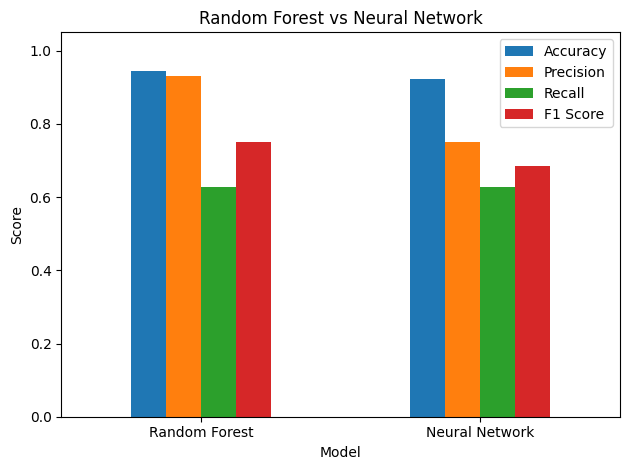

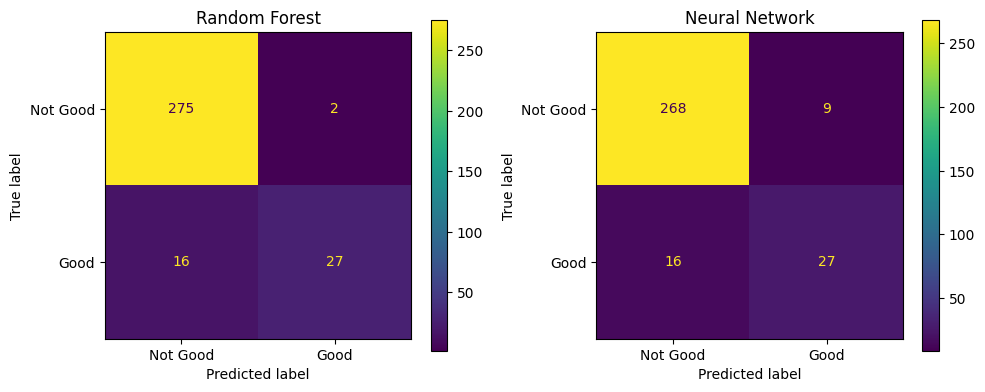

In [ ]:
# TRADITIONAL ML VS NEURAL NETWORK
# WINE QUALITY CLASSIFICATION

import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# 1. LOAD DATASET

url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-red.csv"
)

df = pd.read_csv(url, sep=";")

print(df.head())
print("\nDataset shape:", df.shape)

# 2. CREATE CLASSIFICATION TARGET

df["good_wine"] = (df["quality"] >= 7).astype(int)

X = df.drop(columns=["quality", "good_wine"])
y = df["good_wine"]

print("\nClass distribution:")
print(y.value_counts())

# 3. TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 4. SCALE FEATURES

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. RANDOM FOREST

start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_time = time.time() - start

# 6. NEURAL NETWORK

start = time.time()

nn = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    max_iter=1000,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

nn_pred = nn.predict(X_test_scaled)

nn_time = time.time() - start

# 7. MODEL EVALUATION

def evaluate(name, actual, predicted, train_time):

    return {
        "Model": name,
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted),
        "Recall": recall_score(actual, predicted),
        "F1 Score": f1_score(actual, predicted),
        "Training Time": train_time
    }


results = pd.DataFrame([
    evaluate(
        "Random Forest",
        y_test,
        rf_pred,
        rf_time
    ),

    evaluate(
        "Neural Network",
        y_test,
        nn_pred,
        nn_time
    )
])

print("\nMODEL COMPARISON")
print(results.round(4))

# 8. PERFORMANCE VISUALIZATION

results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(kind="bar")

plt.title("Random Forest vs Neural Network")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 9. CONFUSION MATRICES

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    ax=axes[0],
    display_labels=["Not Good", "Good"]
)

axes[0].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nn_pred,
    ax=axes[1],
    display_labels=["Not Good", "Good"]
)

axes[1].set_title("Neural Network")

plt.tight_layout()
plt.show()